# Low Carbon Index Tracking Portfolio — CalPERS Case Study
### Ecole des Mines Paris Tech · Mastère OSE 2025-2026 · Climate Change Finance

**Objective:** Build a low-carbon version of the S&P500 for CalPERS that simultaneously:
1. Reduces carbon footprint/intensity by **≥ 50%** vs the S&P500 benchmark  
2. Controls tracking error at **3–5%**  
3. Preserves or improves the **Sharpe ratio**

**Method:** Positive screening (50 stocks) + 6 portfolio optimization strategies, out-of-sample backtest (1991–2019), 2-year rolling window, quarterly rebalancing.


## 0. Imports & Setup

In [40]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

COLORS = {
    'Max ENC (Dollar)'   : '#2196F3',
    'Max ENC (Risk)'     : '#4CAF50',
    'Min Variance'       : '#FF9800',
    'Max Diversification': '#9C27B0',
    'Max Decorrelation'  : '#F44336',
    'Min Tracking Error' : '#00BCD4',
    'S&P500'             : '#37474F',
}

DATA_PATH = 'case study - Individual_stock_data.xlsx'

## 1. Data Loading

Three sheets from the Excel file:
- **stock prices** — weekly prices for 505 S&P500 constituents (1989–2019)
- **carbon footprint data** — Scope 1 & 2 emissions, market cap, revenues per stock
- **SP500** — S&P500 Total Return Index (benchmark)


In [41]:
df_prices_raw = pd.read_excel(DATA_PATH, sheet_name='stock prices',
                               index_col=0, parse_dates=True)
df_carbon_raw = pd.read_excel(DATA_PATH, sheet_name='carbon footprint data',
                               index_col=0)
df_sp500_raw  = pd.read_excel(DATA_PATH, sheet_name='SP500',
                               index_col=0, parse_dates=True)

# Convert prices to numeric (some cells contain 'NA' strings)
df_prices = df_prices_raw.apply(pd.to_numeric, errors='coerce')
df_sp500  = pd.to_numeric(df_sp500_raw.iloc[:, 0])

# Compute carbon metrics from raw Scope 1 & 2 columns
# (Excel formula columns are read as strings — we recompute them)
df_c = df_carbon_raw.copy()
df_c['SCOPE1']       = pd.to_numeric(df_c['SCOPE1'], errors='coerce')
df_c['SCOPE2']       = pd.to_numeric(df_c['SCOPE2'], errors='coerce')
df_c['EMISSIONS']    = df_c['SCOPE1'] + df_c['SCOPE2']
df_c['MARKET_VALUE'] = pd.to_numeric(df_c['MARKET_VALUE'], errors='coerce')
df_c['REVENUES']     = pd.to_numeric(df_c['REVENUES'],     errors='coerce')

# Carbon Footprint = Emissions / Market Cap  (tCO2 per $M invested)
# in excel values are in Millions of $ and ktCO2
df_c['FOOTPRINT'] = df_c['EMISSIONS'] / df_c['MARKET_VALUE'] * 1000
# Carbon Intensity = Emissions / Revenues   (tCO2 per $M revenue)
df_c['INTENSITY'] = df_c['EMISSIONS'] / df_c['REVENUES']    * 1000

print(f"Prices     : {df_prices.shape[0]:,} weeks × {df_prices.shape[1]} stocks")
print(f"Date range : {df_prices.index[0].date()} → {df_prices.index[-1].date()}")
print(f"Carbon data: {len(df_c)} stocks across {df_c['SECTOR_NAME'].nunique()} sectors")
print(f"SP500  : {len(df_sp500)}")


Prices     : 1,567 weeks × 505 stocks
Date range : 1989-12-05 → 2019-12-10
Carbon data: 505 stocks across 11 sectors
SP500  : 1567


## 2. S&P500 Carbon Baseline

We compute the cap-weighted carbon profile of the S&P500 as our reference.  
Both **carbon footprint** (tCO₂ / $M invested) and **carbon intensity** (tCO₂ / $M revenue) are computed.  
Our target is to reduce both by at least **50%**.


In [42]:
# Cap-weighted benchmark carbon metrics
total_mktcap        = df_c['MARKET_VALUE'].sum()
df_c['W_BENCH']     = df_c['MARKET_VALUE'] / total_mktcap

sp500_footprint = float((df_c['FOOTPRINT'] * df_c['W_BENCH']).sum())
sp500_intensity = float((df_c['INTENSITY'] * df_c['W_BENCH']).sum())
TARGET_FP       = sp500_footprint * 1
TARGET_INT      = sp500_intensity * 1

print("─" * 55)
print(f"  S&P500 Carbon Footprint  : {sp500_footprint:>8.2f}  tCO₂/$M invested")
print(f"  S&P500 Carbon Intensity  : {sp500_intensity:>8.2f}  tCO₂/$M revenue")
print("─" * 55)
print(f"  Target (−50%) Footprint  : {TARGET_FP:>8.2f}")
print(f"  Target (−50%) Intensity  : {TARGET_INT:>8.2f}")
print("─" * 55)


───────────────────────────────────────────────────────
  S&P500 Carbon Footprint  :    55.69  tCO₂/$M invested
  S&P500 Carbon Intensity  :   122.11  tCO₂/$M revenue
───────────────────────────────────────────────────────
  Target (−50%) Footprint  :    55.69
  Target (−50%) Intensity  :   122.11
───────────────────────────────────────────────────────


In [43]:
# Carbon profile by sector
sector_carbon = df_c.groupby('SECTOR_NAME').apply(lambda g: pd.Series({
    'N stocks'        : len(g),
    'Bench weight (%)': round(g['W_BENCH'].sum() * 100, 2),
    'Avg Footprint'   : round(g['FOOTPRINT'].mean(), 1),
    'Avg Intensity'   : round(g['INTENSITY'].mean(), 1),
})).sort_values('Avg Intensity', ascending=False)

display(sector_carbon)


,N stocks,Bench weight (%),Avg Footprint,Avg Intensity
SECTOR_NAME,,,,
Util,28.0,3.16,1297.1,2718.7
Materials,28.0,2.65,355.5,652.5
Energy,28.0,4.20,375.2,509.6
Industrial,69.0,9.20,209.0,215.6
Real Estate,32.0,2.82,19.7,126.5
Consumer Discretionary,64.0,10.18,56.1,70.8
Consumer Staples,33.0,7.97,66.9,66.9
IT,69.0,22.72,13.0,29.6
Communication Services,27.0,10.56,17.4,21.6


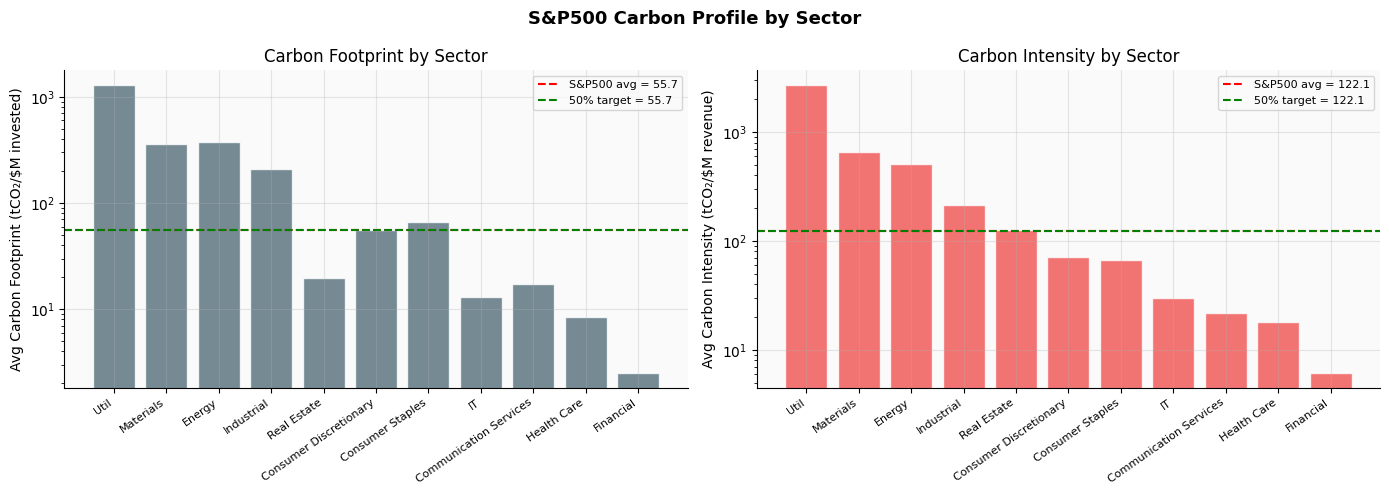

→ Utilities, Energy and Materials are the dominant carbon emitters


In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('S&P500 Carbon Profile by Sector', fontsize=13, fontweight='bold')

sectors = sector_carbon.index
x = np.arange(len(sectors))

# Footprint
bars1 = ax1.bar(x, sector_carbon['Avg Footprint'], color='#546E7A', alpha=0.8, edgecolor='white')
ax1.axhline(sp500_footprint, color='red', ls='--', lw=1.5, label=f'S&P500 avg = {sp500_footprint:.1f}')
ax1.axhline(TARGET_FP, color='green', ls='--', lw=1.5, label=f'50% target = {TARGET_FP:.1f}')
ax1.set_xticks(x); ax1.set_xticklabels(sectors, rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Avg Carbon Footprint (tCO₂/$M invested)'); ax1.legend(fontsize=8)
ax1.set_yscale('log'); ax1.set_title('Carbon Footprint by Sector')

# Intensity
ax2.bar(x, sector_carbon['Avg Intensity'], color='#EF5350', alpha=0.8, edgecolor='white')
ax2.axhline(sp500_intensity, color='red', ls='--', lw=1.5, label=f'S&P500 avg = {sp500_intensity:.1f}')
ax2.axhline(TARGET_INT, color='green', ls='--', lw=1.5, label=f'50% target = {TARGET_INT:.1f}')
ax2.set_xticks(x); ax2.set_xticklabels(sectors, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Avg Carbon Intensity (tCO₂/$M revenue)'); ax2.legend(fontsize=8)
ax2.set_yscale('log'); ax2.set_title('Carbon Intensity by Sector')

plt.tight_layout()
plt.show()
print("→ Utilities, Energy and Materials are the dominant carbon emitters")


- prendre une pondération dans mon prtefeuille des 50 qui représente le meme pourcentage que celui de la représentation dans le SNP500, ca va permettre de probablement diminuer la tracking error
- mais en meme temps si on veut pas de biais sectoriel ce serait mieux de prendre le même nb pr chaque secteur, ptet qu'il y a un biais qui fait que les entreprises de certains secteurs sont moins représentées dans le S&P500, ou bien aussi ce st ptet des secterus qui ont besoin de moins d'entreprises, auquel cas il faut viser atteindre la même proportion de market cap au sein de chaque secteur (par exemple prendre l'ensemble des entreprises qui pour chaque secteru représentent 20% de al capitalisation du secteur, mais ic on est limité car on a pas les données de cap totaux de chaque secteur).
- cependant la carbon footprint a comme default qu'elle sous évalue l'impact carbone des entreprises à frote capitalisation, voir potentiellement surévaluées, 
- la carbone intensity montre réellement cb l'entreprise pollue pr faire de la valeur, mais elle souffre d'un fort biais sectoriel.
- Le choix le plus logique me semble être de s'intéresser à l'intensité carbone, car c'est une meilleure métrique pour vérifier l'efficacité de chaque entreprise à produire de la richesse, et pr répoondre au biais secto le mieux est pour moi de prendre la meme part que celle de chaque secteur dans le snp 500

encore mieux, je devrais prendre une representation de chaque secteru pas en poids de capitalisation ds le snp500 mais au nombre d'entreprise dans le s&p500, mais on va encore une fois plus devier je pense du S&P500 et avoir une frote tracking error, bon je vais tester comme vu plus haut dans un premier temps ( a tester ares et voir si on peut demonter mathématiquement qu'une solution est meilleure).

ok non, si je choisi les entreprises selon la ponderation dans le s&p500, je vais moins bien diversifier, il vaut mieux faire comme si on s'intéresser à un EW

## 3. Stock Selection — Positive Screening (50 stocks)

**Methodology:**
cf au dessus

potentiellement pas se limiter à 50, ou test 50 et 100

comment gérer les arrondis ?
regarder à partir de quelle date on s'intéresse au problème (en premier lieu pour avoir les meilleures entreprises de notre portefeuille)

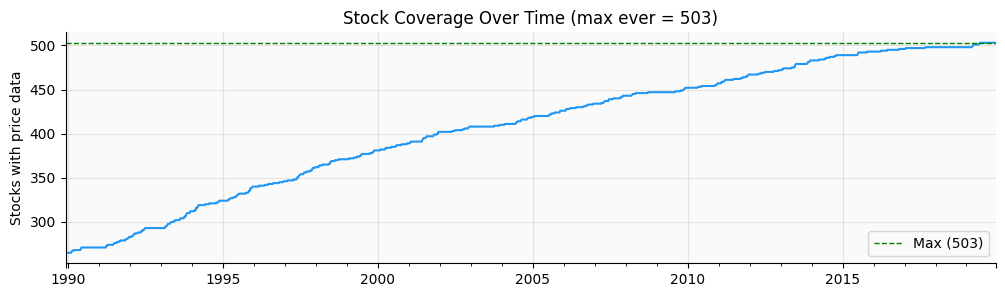

Threshold : 80% of max = 402 stocks
Start date: 2001-12-18

Universe at 2001-12-18: 276 stocks with carbon data
SECTOR_NAME
Financial                 38
Health Care               37
Industrial                36
IT                        35
Consumer Discretionary    30
Consumer Staples          28
Util                      19
Materials                 17
Real Estate               17
Energy                    12
Communication Services     7
Name: count, dtype: int64

Sector quotas (total = 49):
  Financial                   :  7 stocks  (S&P500 weight: 13.8%)
  Health Care                 :  7 stocks  (S&P500 weight: 13.4%)
  Industrial                  :  7 stocks  (S&P500 weight: 13.0%)
  IT                          :  6 stocks  (S&P500 weight: 12.7%)
  Consumer Discretionary      :  5 stocks  (S&P500 weight: 10.9%)
  Consumer Staples            :  5 stocks  (S&P500 weight: 10.1%)
  Util                        :  3 stocks  (S&P500 weight: 6.9%)
  Materials                   :  3 stocks

In [45]:
N_SELECT = 50   # 

# ── Step 1: Find first date where coverage reaches a threshold ──
coverage_over_time = df_prices.notna().sum(axis=1)

plt.figure(figsize=(12, 3))
coverage_over_time.plot(color='#2196F3')
plt.ylabel('Stocks with price data')
plt.title('Stock Coverage Over Time (max ever = 503)')
plt.axhline(503, color='green', ls='--', lw=1, label='Max (503)')
plt.legend(); plt.show()

# Max coverage is 503 — pick a threshold (e.g. 95% = 478 stocks)
COVERAGE_THRESHOLD = 0.8
min_stocks = int(coverage_over_time.max() * COVERAGE_THRESHOLD)
start_date = coverage_over_time[coverage_over_time >= min_stocks].index[0]

print(f"Threshold : {COVERAGE_THRESHOLD:.0%} of max = {min_stocks} stocks")
print(f"Start date: {start_date.date()}")

# ── Step 2: Universe = stocks available at start_date WITH carbon data ──
available_at_start = df_prices.loc[start_date].dropna().index.tolist()
universe = [
    t for t in available_at_start
    if t in df_c.index
    and pd.notna(df_c.loc[t, 'INTENSITY'])
    and pd.notna(df_c.loc[t, 'MARKET_VALUE'])
]
df_u = df_c.loc[universe].copy()

print(f"\nUniverse at {start_date.date()}: {len(universe)} stocks with carbon data")
print(df_u['SECTOR_NAME'].value_counts())

# ── Step 3: Compute sector quotas = mirror S&P500 sector cap weights ──
# S&P500 sector weights = each sector's total market cap / total S&P500 market cap
# sp500_sector_weights = (
#     df_c.groupby('SECTOR_NAME')['MARKET_VALUE'].sum()
#     / df_c['MARKET_VALUE'].sum()
# )

#S&P500 sector proportions : each sector number of companies in the selected unvierse / total number of companies in the selected universe
sp500_sector_proportions = df_u['SECTOR_NAME'].value_counts() / len(df_u)

# Allocate N_SELECT stocks proportionally across sectors
raw_quotas = (sp500_sector_proportions * N_SELECT).round()
quotas = raw_quotas.astype(int)

# # Adjust rounding to hit exactly N_SELECT
# diff = N_SELECT - quotas.sum()
# # Add/remove from largest sectors first
# sorted_sectors = sp500_sector_proportions.sort_values(ascending=False).index
# i = 0
# while diff != 0:
#     s = sorted_sectors[i % len(sorted_sectors)]
#     max_avail = df_u[df_u['SECTOR_NAME'] == s].shape[0]
#     if diff > 0 and quotas[s] < max_avail:
#         quotas[s] += 1; diff -= 1
#     elif diff < 0 and quotas[s] > 1:
#         quotas[s] -= 1; diff += 1
#     i += 1
# or not if it is different than 50 maybe it is for the better

print(f"\nSector quotas (total = {quotas.sum()}):")
for s, q in quotas.sort_values(ascending=False).items():
    w = sp500_sector_proportions[s]
    print(f"  {s:<28}: {q:>2} stocks  (S&P500 weight: {w:.1%})")

# ── Step 4: Within each sector, pick lowest carbon intensity ──
selected_tickers = []
for sector, n_pick in quotas.items():
    if n_pick == 0:
        continue
    sector_stocks = df_u[df_u['SECTOR_NAME'] == sector]
    if len(sector_stocks) == 0:
        print(f"  WARNING: no stocks available for {sector}")
        continue
    picked = (sector_stocks
              .sort_values('INTENSITY', ascending=True)
              .head(n_pick)
              .index.tolist())
    selected_tickers.extend(picked)

df_sel = df_c.loc[selected_tickers].copy()

# ── Step 5: Summary ──
print(f"\nSelected {len(selected_tickers)} stocks from {start_date.date()}")

sp500_intensity = float((df_c['INTENSITY'] * df_c['MARKET_VALUE'] / df_c['MARKET_VALUE'].sum()).sum())
sel_intensity   = df_sel['INTENSITY'].mean()

print(f"\nCarbon intensity (equal-weight):")
print(f"  Selected portfolio : {sel_intensity:.2f} tCO₂/$M revenue")
print(f"  S&P500 benchmark   : {sp500_intensity:.2f} tCO₂/$M revenue")
print(f"  Reduction          : {(1 - sel_intensity/sp500_intensity)*100:.1f}%")

print("\nSelected stocks by sector:")
print(df_sel.groupby('SECTOR_NAME').agg(
    N=('INTENSITY','count'),
    Avg_Intensity=('INTENSITY','mean')
).round(1))

## 4. Price Data Preparation

Weekly returns computed from prices. Forward-filled gaps. SP500 returns aligned on same dates.  
Benchmark weights = cap-weighted within selected 50 stocks (renormalized).


In [46]:
# ── Return series: start from start_date where all stocks are present ──
prices     = df_prices[selected_tickers].loc[start_date:]
returns    = prices.pct_change().dropna(how='any')   # drops only the first row (no prior price)

sp500_rets = df_sp500.pct_change().dropna()
sp500_rets = sp500_rets.loc[returns.index]           # align SP500 to same dates

# ── Carbon vectors ──
c_fp  = df_sel['FOOTPRINT'].values
c_int = df_sel['INTENSITY'].values
N     = len(selected_tickers)

print(f"Returns    : {returns.shape[0]:,} weeks × {returns.shape[1]} stocks")
print(f"Date range : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"N          : {N} stocks")

Returns    : 938 weeks × 49 stocks
Date range : 2001-12-25 → 2019-12-10
N          : 49 stocks


## 5. Optimization Engine

Each strategy solves a constrained optimization at each rebalancing date.

**Constraints applied to ALL strategies:**
- Long-only: $w_i \geq 0$
- Full investment: $\sum w_i = 1$
- Max weight: $w_i \leq 20\%$ (concentration limit)
- Carbon footprint constraint: $\mathbf{w}^\top \mathbf{c}_{fp} \leq$ target
- Carbon intensity constraint: $\mathbf{w}^\top \mathbf{c}_{int} \leq$ target

| Strategy | Objective |
|---|---|
| **Max ENC (Dollar)** | $\min \sum w_i^2$ → closest to equal-weight |
| **Max ENC (Risk)** | Risk Parity: equalize $RC_i = w_i \frac{\partial \sigma_p}{\partial w_i}$ |
| **Min Variance** | $\min \mathbf{w}^\top \Sigma \mathbf{w}$ |
| **Max Diversification** | $\max \frac{\mathbf{w}^\top \boldsymbol{\sigma}}{\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}}$ |
| **Max Decorrelation** | $\min \mathbf{w}^\top \mathbf{C} \mathbf{w}$ (on correlation matrix) |
| **Min Tracking Error** | $\min (\mathbf{w}-\mathbf{w}_b)^\top \Sigma (\mathbf{w}-\mathbf{w}_b)$ |


faire une description (plus demo pour moi de chacun) et passer plus de temps sur la partie en dessous

In [47]:
# ── Benchmark weights: real S&P500 cap weights for our selected stocks ──
# Each stock gets its actual weight in the full S&P500 (market cap / total S&P500 market cap)
# This sums to less than 1 (our 49 stocks are only a fraction of the full index)
# We normalize so it sums to 1 — this is the best reachable approximation of the benchmark
# given we can only hold these 49 stocks

total_sp500_mcap = df_c['MARKET_VALUE'].sum()

bw = np.array([
    df_c.loc[t, 'MARKET_VALUE'] / total_sp500_mcap
    for t in selected_tickers
])

bw = bw / bw.sum()   # normalize to sum to 1

print(f"bw: {len(bw)} stocks, sums to {bw.sum():.4f}")
print(f"Largest weight: {bw.max()*100:.1f}%  ({selected_tickers[bw.argmax()]})")
print(f"Smallest weight: {bw.min()*100:.2f}%  ({selected_tickers[bw.argmin()]})")

bw: 49 stocks, sums to 1.0000
Largest weight: 34.1%  (AAPL)
Smallest weight: 0.14%  (ADS)


In [48]:
#let's first start by the Max ENC (effective number of constituants):
#the equation above we need to min is obvious

#let's build the constraints and optim problem
def build_constraints():
    return [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq', 'fun': lambda w: TARGET_INT - float(w @ c_int)},
        {'type': 'ineq', 'fun': lambda w: TARGET_FP  - float(w @ c_fp)},
    ], [(0.0, 1)] * N

def optimize(obj,cov, w0=None):
    constraints, bounds = build_constraints()
    if w0 is None:
        w0 = np.ones(N) / N
    res = minimize(obj, w0, method='SLSQP', bounds=bounds,
                   constraints=constraints,
                   options={'maxiter': 2000, 'ftol': 1e-10})
    w = np.maximum(res.x if res.success else w0, 0)  # ?
    return w / w.sum()

def strat_max_enc_dollar(cov):
    return optimize(lambda w: np.sum(w**2), cov)

def strat_max_enc_risk(cov):
    def obj(w):
        pvar = float(w @ cov @ w)
        rc   = w * (cov @ w) / pvar
        return float(np.sum((rc - 1/N)**2))
    return optimize(obj, cov)

def strat_min_variance(cov):
    return optimize(lambda w: float(w @ cov @ w), cov)

def strat_max_diversification(cov):
    vols = np.sqrt(np.diag(cov))
    def obj(w):
        pv = np.sqrt(float(w @ cov @ w))
        return -float(w @ vols) / pv if pv > 0 else 0
    return optimize(obj, cov)

def strat_max_decorrelation(cov):
    vols = np.sqrt(np.diag(cov))
    corr = cov / np.outer(vols, vols)
    return optimize(lambda w: float(w @ corr @ w), cov)

# def strat_min_tracking_error(cov):
#     return optimize(lambda w: float((w - bw) @ cov @ (w - bw)), cov, w0=bw.copy())

def strat_min_tracking_error(cov, ret_window, sp500_window):
    R = ret_window.values
    def obj(w):
        diff = R @ w - sp500_window
        return float(diff.var())
    return optimize(obj, cov, w0=bw.copy())

STRATEGIES = {
    'Max ENC (Dollar)'   : strat_max_enc_dollar,
    'Max ENC (Risk)'     : strat_max_enc_risk,
    'Min Variance'       : strat_min_variance,
    'Max Diversification': strat_max_diversification,
    'Max Decorrelation'  : strat_max_decorrelation,
    'Min Tracking Error' : strat_min_tracking_error,
}
print("Optimization engine ready ✓")

Optimization engine ready ✓


In [49]:
# Now we want to see this strategy in action, we are going to use it for our quaterly rebalancing, from start date to finish,

CALIB  = 104   # 2-year rolling window
REBAL  = 13    # quarterly

n_dates    = len(returns)
rebal_idxs = list(range(CALIB, n_dates, REBAL))
all_dates  = returns.index
# print(all_dates[rebal_idxs]) by using this i can get the index of all the weeks we are doing rebalancing

print(f"Backtest period : {all_dates[CALIB].date()} → {all_dates[-1].date()}")
print(f"Rebalancings    : {len(rebal_idxs)}")


def run_backtest(strategy_fn, strategy_name): #take a strat and its name as input
    port_rets, port_dates, wt_list = [], [], [] # one portfolio return per week, the date, and the weights
    for i, idx in enumerate(rebal_idxs): #loops over the rebalancing dates
        ret_window   = returns.iloc[idx - CALIB : idx]           #estimate the covariance on the past 2 years of data
        sp500_window = sp500_rets.iloc[idx - CALIB : idx].values  # S&P500 returns over the same 2-year window
        cov = ret_window.cov().values.copy() * 52  #annualize it, BIG ASSUMPTION, we suppose weeks are not correlated
        cov += np.eye(N) * 1e-8                     # Tikhonov regularization: ensure positive definiteness
        
        # Min TE needs the actual return series to minimize realized TE directly
        # all other strategies only need the covariance matrix
        if strategy_name == 'Min Tracking Error':
            w = strat_min_tracking_error(cov, ret_window, sp500_window)
        else:
            w = strategy_fn(cov) #runs the optimization and gets the weights for the current rebalancing period
        
        wt_list.append(w.copy()) #save it for later analysis
        end = rebal_idxs[i+1] if i+1 < len(rebal_idxs) else n_dates #end of the current rebalancing period is the next rebalancing date, or the end of the data
        w_t = w.copy() # WILL USE IT TO LOOP ON EVERY WEEK OF THE PERIOD
        for t in range(idx, end): # for every week in the period
            r_t = returns.iloc[t].values # get the N stocks returns for week t
            port_rets.append(float(w_t @ r_t)) #portfolio returns of the week
            port_dates.append(all_dates[t]) #record the related date
            # buy-and-hold drift
            w_t = w_t * (1 + r_t) # new weights for the next week, let it drift
            if w_t.sum() > 0:
                w_t /= w_t.sum() # the sum must still be 1, we renormalize
    return pd.Series(port_rets, index=port_dates), wt_list # return a time series of the return with the related weight vectors

results, weights_hist = {}, {}
for name, fn in STRATEGIES.items():
    print(f"  Running {name}...", end=' ', flush=True)
    r, w = run_backtest(fn, name)  # pass strategy name so Min TE is handled correctly
    results[name] = r
    weights_hist[name] = w
    print("done")

print("\n✓ All strategies backtested")

Backtest period : 2003-12-23 → 2019-12-10
Rebalancings    : 65
  Running Max ENC (Dollar)... done
  Running Max ENC (Risk)... done
  Running Min Variance... done
  Running Max Diversification... done
  Running Max Decorrelation... done
  Running Min Tracking Error... done

✓ All strategies backtested


## 7. Performance Analysis

In [ ]:
def metrics(port_rets, sp_rets):
    # ── align on common dates in case the two series don't perfectly overlap ──
    common = port_rets.index.intersection(sp_rets.index)
    pr = port_rets.loc[common]   # pr = portfolio returns (weekly), clipped to common dates
    sr = sp_rets.loc[common]     # sr = benchmark (S&P500) returns (weekly), same dates

    ann_ret = pr.mean() * 52          # annualized return: avg weekly return × 52 weeks
    ann_vol = pr.std() * np.sqrt(52)  # annualized volatility: weekly std × √52
                                      # (√52 not ×52 because vol scales with √time, not time)
    te = (pr - sr).std() * np.sqrt(52)  # tracking error: annualized std of weekly active returns
                                         # active return = portfolio return - benchmark return each week

    cum   = (1 + pr).cumprod()           # cumulative wealth index: $1 compounded week by week
    dd    = (cum / cum.cummax() - 1).min() # max drawdown: worst % fall from any previous peak
                                            # cummax() = running maximum of the wealth index
                                            # .min() picks the worst trough-to-peak ratio

    return {
        'Ann. Return (%)' : round(ann_ret * 100, 2),
        'Ann. Vol (%)'    : round(ann_vol * 100, 2),
        'Sharpe Ratio'    : round(ann_ret / ann_vol, 3) if ann_vol > 0 else 0,  
                            # return per unit of risk, risk-free rate assumed = 0
        'Track. Error (%)': round(te * 100, 2),
        'Cum. Return (%)'  : round(((1 + pr).prod() - 1) * 100, 1),  
                             # total compounded return over full period
                             # .prod() multiplies all (1+r_t) together = final wealth
                             # -1 converts wealth index back to return
        'Max Drawdown (%)': round(dd * 100, 2),
    }

# ── S&P500 over the backtest period only ──
# results[list(results.keys())[0]].index[0] = first date of the first strategy's return series
# = the first date after the 2-year warmup period
sp500_backtest = sp500_rets.loc[results[list(results.keys())[0]].index[0]:]

perf = {}
perf['S&P500'] = metrics(sp500_backtest, sp500_backtest)  # same series for both args → TE = 0
perf['S&P500']['Track. Error (%)'] = 0.0                  # overwrite explicitly to avoid floating point noise

for name, r in results.items():
    perf[name] = metrics(r, sp500_backtest)   # each strategy vs the real S&P500

perf_df = pd.DataFrame(perf).T
display(perf_df.style
    .background_gradient(subset=['Sharpe Ratio'],     cmap='RdYlGn')
    .background_gradient(subset=['Track. Error (%)'], cmap='RdYlGn_r')  # reversed: low TE = green
    .background_gradient(subset=['Ann. Return (%)'],  cmap='RdYlGn')
    .format('{:.2f}'))

,Ann. Return (%),Ann. Vol (%),Sharpe Ratio,Track. Error (%),Cum. Return (%),Max Drawdown (%)
S&P500,9.89,15.17,0.65,0.00,304.90,-53.98
Max ENC (Dollar),15.30,17.30,0.88,5.21,808.90,-59.19
Max ENC (Risk),14.74,15.12,0.97,4.58,780.60,-53.89
Min Variance,12.79,11.92,1.07,9.23,591.80,-42.60
Max Diversification,14.16,14.85,0.95,7.94,708.70,-54.07
Max Decorrelation,15.45,18.81,0.82,10.92,798.70,-59.79
Min Tracking Error,12.76,15.86,0.81,4.49,529.80,-57.35


OBJECTIVE:
- understand why mean tracking error doesn't have the min tracking error
verify each indep result 
test for more sample


- how everything works (bc there is many errors I feel like)
- next steps (analysis and more tets)
les portefeuilles devraient ils avoir un minimum pr representer les secteurs choisis ? il y a des stocks à 0% meme ds les max dic et tt ?

DONE:

To do:
- sp
- max enc
- enc risk
- min var
- max div
- max decor
- min TE


In [55]:
# ── Portfolio Diagnostics ──
# Change these two parameters to explore
STRATEGY_TO_INSPECT = 'Max Decorrelation'   # ← change strategy here
REBAL_STEP = 10   # ← 0 = first rebalancing, -1 = last, any integer in between

# ── 1. Average weights across ALL rebalancings, sorted by size ──
print(f"\n{'═'*55}")
print(f"  AVERAGE WEIGHTS — {STRATEGY_TO_INSPECT}")
print(f"{'═'*55}")

avg_w = np.mean(weights_hist[STRATEGY_TO_INSPECT], axis=0)
order = np.argsort(avg_w)[::-1]   # sort descending

cum = 0
for rank, j in enumerate(order):
    ticker  = selected_tickers[j]
    w       = avg_w[j]
    sector  = df_sel.loc[ticker, 'SECTOR_NAME']
    intens  = df_sel.loc[ticker, 'INTENSITY']
    cum    += w
    print(f"  {rank+1:>3}. {ticker:<6} {w*100:>6.2f}%  cumul:{cum*100:>6.1f}%  "
          f"| {sector:<28} | intensity: {intens:>7.1f}")

print(f"\n  Effective N (1/Σw²)     : {1/np.sum(avg_w**2):.1f}  (max possible = {N})")
print(f"  Avg carbon intensity     : {float(avg_w @ c_int):.2f}  (target ≤ {TARGET_INT:.2f})")
print(f"  Avg carbon footprint     : {float(avg_w @ c_fp):.2f}  (target ≤ {TARGET_FP:.2f})")
print(f"  Stocks with w > 10%      : {(avg_w > 0.10).sum()}")
print(f"  Stocks with w < 0.1%     : {(avg_w < 0.001).sum()}  (effectively zero)")

# ── 2. Weights at a specific rebalancing step ──
print(f"\n{'═'*55}")
print(f"  WEIGHTS AT REBALANCING STEP {REBAL_STEP} "
      f"({all_dates[rebal_idxs[REBAL_STEP]].date()}) — {STRATEGY_TO_INSPECT}")
print(f"{'═'*55}")

w_step = weights_hist[STRATEGY_TO_INSPECT][REBAL_STEP]
order_step = np.argsort(w_step)[::-1]

cum = 0
for rank, j in enumerate(order_step):
    if w_step[j] < 0.001:   # skip near-zero weights
        continue
    ticker = selected_tickers[j]
    w      = w_step[j]
    sector = df_sel.loc[ticker, 'SECTOR_NAME']
    cum   += w
    print(f"  {rank+1:>3}. {ticker:<6} {w*100:>6.2f}%  cumul:{cum*100:>6.1f}%  "
          f"| {sector:<28}")

print(f"\n  Carbon intensity this step: {float(w_step @ c_int):.2f}  (target ≤ {TARGET_INT:.2f})")
print(f"  Carbon footprint this step: {float(w_step @ c_fp):.2f}  (target ≤ {TARGET_FP:.2f})")
print(f"  Effective N               : {1/np.sum(w_step**2):.1f}")

# ── 3. Sector breakdown ──
print(f"\n{'═'*55}")
print(f"  SECTOR BREAKDOWN — {STRATEGY_TO_INSPECT} (average)")
print(f"{'═'*55}")

sector_w = {}
for j, ticker in enumerate(selected_tickers):
    s = df_sel.loc[ticker, 'SECTOR_NAME']
    sector_w[s] = sector_w.get(s, 0) + avg_w[j]

sp500_sector_w = df_c.groupby('SECTOR_NAME')['MARKET_VALUE'].sum() / df_c['MARKET_VALUE'].sum()

print(f"  {'Sector':<28} {'Portfolio':>10} {'S&P500':>10} {'Diff':>8}")
print(f"  {'-'*28} {'-'*10} {'-'*10} {'-'*8}")
for s, w in sorted(sector_w.items(), key=lambda x: -x[1]):
    sp_w = sp500_sector_w.get(s, 0)
    print(f"  {s:<28} {w*100:>9.2f}%  {sp_w*100:>9.2f}%  {(w-sp_w)*100:>+7.2f}%")


═══════════════════════════════════════════════════════
  AVERAGE WEIGHTS — Max Decorrelation
═══════════════════════════════════════════════════════
    1. ED       6.68%  cumul:   6.7%  | Util                         | intensity:   349.2
    2. HUM      6.23%  cumul:  12.9%  | Health Care                  | intensity:     2.0
    3. MO       5.89%  cumul:  18.8%  | Consumer Staples             | intensity:    17.3
    4. AIG      5.02%  cumul:  23.8%  | Financial                    | intensity:     0.2
    5. AAPL     4.62%  cumul:  28.4%  | IT                           | intensity:     3.2
    6. BKR      4.58%  cumul:  33.0%  | Energy                       | intensity:    30.9
    7. NVDA     4.25%  cumul:  37.3%  | IT                           | intensity:     4.6
    8. HAS      4.14%  cumul:  41.4%  | Consumer Discretionary       | intensity:     3.2
    9. AVB      3.79%  cumul:  45.2%  | Real Estate                  | intensity:    35.6
   10. SHW      3.48%  cumul:  48.7%  |